# Fault Classification
- **Objective:** To classify fault types

In [9]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
# Read data file
df = pd.read_csv('lighting_data_cleaned.csv')

# Display data
df

,light_id,location_name,fault_type,timestamp,severity_level,fault_status,maintenance_cost,year,month,day,day_of_week,hour
0,L0602,Chinatown,Power-Related,2020-01-06 06:34:34,Informational,Resolved,435.43,2020,1,6,Monday,6
1,L0616,Bishan,Power-Related,2020-01-06 09:20:51,Informational,Acknowledged,456.65,2020,1,6,Monday,9
2,L0199,Bugis Junction,Power-Related,2020-01-06 19:45:33,Critical,Closed,336.82,2020,1,6,Monday,19
3,L0036,Chinatown,Power-Related,2020-01-07 10:49:23,High,Resolved,368.61,2020,1,7,Tuesday,10
4,L0259,Pasir Ris,Power-Related,2020-01-08 16:49:23,Critical,Closed,179.93,2020,1,8,Wednesday,16
...,...,...,...,...,...,...,...,...,...,...,...,...
189,L0718,Pasir Ris,Control System,2020-12-27 07:38:39,Critical,Resolved,482.28,2020,12,27,Sunday,7
190,L0539,Bugis Junction,Communication,2020-12-28 03:03:47,Informational,Detected,183.64,2020,12,28,Monday,3
191,L0281,Outram Park,Power-Related,2020-12-28 03:22:38,High,Closed,380.25,2020,12,28,Monday,3
192,L0169,Bishan,Environmental,2020-12-28 07:31:05,Critical,Detected,308.93,2020,12,28,Monday,7


In [11]:
# Convert fault_type from text to numbers due to ml works on numbers
fault_encoder = LabelEncoder()
df['fault_encoded'] = fault_encoder.fit_transform(df['fault_type'])

# Display original and encoded fault types
df[['fault_type', 'fault_encoded']]

,fault_type,fault_encoded
0,Power-Related,4
1,Power-Related,4
2,Power-Related,4
3,Power-Related,4
4,Power-Related,4
...,...,...
189,Control System,1
190,Communication,0
191,Power-Related,4
192,Environmental,3


In [12]:
# One-hot encode categorical columns into numeric (0/1) features
df_encoded = pd.get_dummies(df, columns=['location_name', 'fault_status', 'severity_level'])

# Display encoded column names
df_encoded.columns

Index(['light_id', 'fault_type', 'timestamp', 'maintenance_cost', 'year',
       'month', 'day', 'day_of_week', 'hour', 'fault_encoded',
       'location_name_Bishan', 'location_name_Bugis Junction',
       'location_name_Canberra', 'location_name_Chinatown',
       'location_name_City Hall', 'location_name_Jurong West',
       'location_name_Orchard Road', 'location_name_Outram Park',
       'location_name_Pasir Ris', 'location_name_Toa Payoh',
       'fault_status_Acknowledged', 'fault_status_Closed',
       'fault_status_Detected', 'fault_status_In Progress',
       'fault_status_Resolved', 'severity_level_Critical',
       'severity_level_High', 'severity_level_Informational',
       'severity_level_Low', 'severity_level_Medium'],
      dtype='object')

In [13]:
# Drop unused columns
df_encoded = df_encoded.drop(columns= ['light_id', 'timestamp', 'fault_type', 'maintenance_cost',	'year', 'day_of_week'])

# Check new columns
df_encoded.head()

,month,day,hour,fault_encoded,location_name_Bishan,location_name_Bugis Junction,location_name_Canberra,location_name_Chinatown,location_name_City Hall,location_name_Jurong West,...,fault_status_Acknowledged,fault_status_Closed,fault_status_Detected,fault_status_In Progress,fault_status_Resolved,severity_level_Critical,severity_level_High,severity_level_Informational,severity_level_Low,severity_level_Medium
0,1,6,6,4,False,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
1,1,6,9,4,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
2,1,6,19,4,False,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
3,1,7,10,4,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,False,False
4,1,8,16,4,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False


In [14]:
# Split data feature X (input data points use to predict) & label y (output/target data points want to predict)

# Remove fault_encoded column
X = df_encoded.drop('fault_encoded', axis=1)

# Target is fault_encoded
y = df_encoded['fault_encoded']

In [15]:
# Split data into input features (X) and target labels (y)

# Features used to predict the fault type
X = df_encoded.drop('fault_encoded', axis=1)

# Target variable (fault type)
y = df_encoded['fault_encoded']

In [16]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% testing
    random_state=42
)

In [17]:
# Create Decision Tree model
clf = DecisionTreeClassifier(random_state=42)

# Train model using training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
# Predict fault types for the test data
y_pred = clf.predict(X_test)

# Display model performance metrics
print(classification_report(
    y_test,
    y_pred,
    target_names=fault_encoder.classes_
))

                precision    recall  f1-score   support

 Communication       0.10      0.10      0.10        10
Control System       0.20      0.17      0.18         6
 Cybersecurity       0.00      0.00      0.00         3
 Environmental       0.29      0.33      0.31         6
 Power-Related       0.00      0.00      0.00         3
Sensor-Related       0.29      0.18      0.22        11

      accuracy                           0.15        39
     macro avg       0.15      0.13      0.14        39
  weighted avg       0.18      0.15      0.16        39



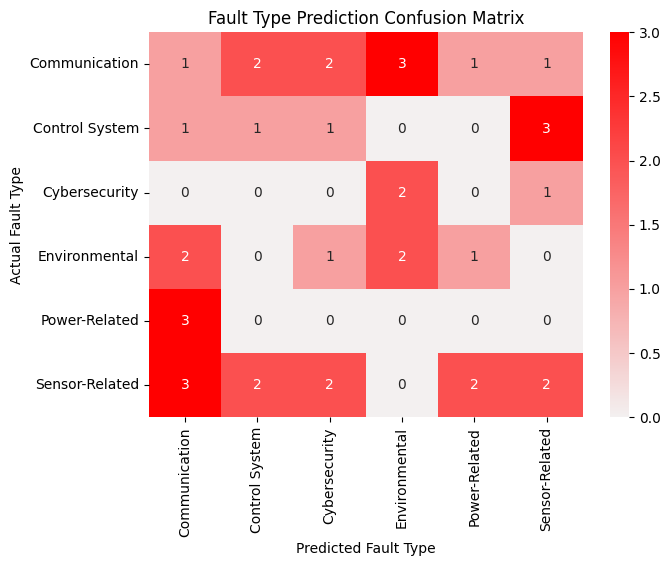

In [19]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a light red colour map
light_red_cmap = sns.light_palette("red", as_cmap=True)

# Set figure size
plt.figure(figsize=(7, 5))

# Display confusion matrix as a heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=fault_encoder.classes_,  # Predicted fault types
    yticklabels=fault_encoder.classes_, # Actual fault types
    cmap=light_red_cmap
)

# Add labels and title
plt.xlabel("Predicted Fault Type")
plt.ylabel("Actual Fault Type")
plt.title("Fault Type Prediction Confusion Matrix")

# Show plot
plt.show()